In [1]:
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.prompts import PromptTemplate, ChatPromptTemplate
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.output_parsers import JsonOutputParser, StrOutputParser
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph, END
import os
from langchain.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from typing import Dict, Any, Optional, TypedDict
import uuid
import json

load_dotenv()

def setup_llm():
    """
    Configura e retorna o modelo LLM do Groq.
    
    Returns:
        ChatGroq: Instância configurada do modelo LLM
    """
    llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.7)
    return llm


class ExtractResume(BaseModel):
    nome: str = Field(description="Nome completo do candidato")
    email: Optional[str] = Field(description="Email do candidato")
    telefone: Optional[str] = Field(description="Número de telefone do candidato")
    endereco: Optional[str] = Field(description="Endereço, cidade ou estado do candidato")
    summary: str = Field(description="Resumo das principais qualificações e experiências")
    linkedin: str = Field(description="URL do perfil do LinkedIn do candidato")

class ReviewResume(BaseModel):
    resume: str = Field(description="Currículo revisado do candidato")

class RecruitamentState(TypedDict):
    """State for the recruitment process."""
    thread_id: str
    cargo: str
    curriculo_text: str
    candidate_email: str
    analysis_result: Dict[str, Any]
    interview_result: Dict[str, Any]
    email_content: str
    error: Optional[str]

In [2]:
def extract_content(file_path) -> str: 
    loader = PyPDFLoader(file_path)
    pages = loader.load()

    for text in pages:
        texto = text.page_content
        return texto

In [ ]:
def analyze_agent(texto: str) -> str:
    llm = setup_llm()
    # Define the prompt template
    prompt = ChatPromptTemplate.from_messages([
    ("system", "Você é um assistente de RH que extrai as informações de um currículo, remove formatações erradas, como espaços em branco, quebras de linha, etc. Não faça comentários ou tentativas de colocar em formatação como negrito, retorne APENAS o texto corrigido "),
    ("user", """Extraia os dados do curriculo e melhore sua formatação.
    Currículo: {texto}"""),
])

    parser = StrOutputParser(pydantic_object=ExtractResume)

    chain = prompt | llm | parser
    # Get the response from the model
    response = chain.invoke(texto)
    
    return response

In [112]:
# cv_revisado = analyze_agent(texto)
# cv_revisado

In [113]:
print(cv_revisado)

Certificados & Cursos

AWS Certified Cloud Practitioner
Amazon Web Services Training e Certification

Microsoft Certified: Azure AI Fundamentals
Microsoft Certified Fundamentals

Open Source Models with Hugging Face
Deep Learning. AI

Natural Language Processing Specialization
Deep Learning. AI

Scoras Academy - Formação em LLMS, Agents
Scoras Digital

Projetos

Chatbot de Atendimento - CELP E
Foi desenvolvido um chatbot inteligente utilizando técnicas de Retrieval-Augmented Generation (RAG) e chatgpt3.5 turbo orquestrado pelo LangChain para automatizar e melhorar o atendimento ao cliente da ENEL. O sistema combina a recuperação de informações de bases de dados internas e notícias externas com a geração de respostas naturais, entregando suporte rápido e preciso.

Pavao AI - UNICAP (Projeto acadêmico)
O projeto desenvolve um sistema baseado em Hugging Face e BERT para análise de comentários do setor de Comissão de Avaliação da UNICAP, com foco na categorização temática e análise de sent

In [114]:
# texto = extract_content("data/aiengineerathospugliese.pdf")

In [ ]:
def sctructured_agent(texto: str) -> str:
    # Initialize the Groq model
    llm = setup_llm()

    # Define the prompt template
    prompt = ChatPromptTemplate.from_messages([
    ("system", "Você é um assistente de RH que extrai informações chaves de um candidato através de um texto não estruturado."),
    ("user", """Extraia os dados do curriculo e retorne um JSON com as seguintes chaves:
    - Nome
    - email
    - telefone
    - Rua, endereço/cidade ou estado
    - resumo
    - linkedin.
    Currículo: {texto}"""),
])

    parser = JsonOutputParser(pydantic_object=ExtractResume)

    chain = prompt | llm | parser
    # Get the response from the model
    response = chain.invoke(texto)
    
    return response

In [116]:
# llm_response = sctructured_agent(texto)
# llm_response

In [117]:
titulo_vaga = "Engenheiro de IA"
descrição_vaga = """Responsibilities and assignments:

Desenvolver e otimizar chatbots utilizando tecnologias de Inteligência Artificial e Machine Learning.
Trabalhar com times de produto e UX para criar soluções de chatbot que atendam às necessidades dos usuários.
Definir a arquitetura técnica dos chatbots e integrar com sistemas e plataformas existentes.
Apoiar o crescimento técnico da equipe, fornecendo orientação para desenvolvedores mais juniores.
Gerenciar e otimizar a performance dos chatbots com base em dados de uso.
Desenvolver soluções rápidas, alinhadas aos objetivos da empresa, sem comprometer a qualidade.
Balancear inovação técnica com as demandas práticas do negócio.

Requirements and qualifications:

Conhecimento em IA e Machine Learning, com foco em Processamento de Linguagem Natural (NLP).
Experiência em desenvolvimento de software com linguagens como Python, Java ou similares.
Conhecimento em práticas ágeis e desenvolvimento colaborativo.
Boa comunicação e colaboração com times de diferentes áreas;
Necessário experiência em Low-code.

Additional information:
Experiência com frameworks de IA, como TensorFlow, PyTorch, Rasa
Experiência com Google CCAI / Dialogflow
Experiência com soluções omnichannel (integração de chatbot com canais de voz e texto).
Conhecimento em Cloud Computing (AWS, Azure, GCP)."""

# Armazena requisitos predefinidos para diferentes funções, a IA vai combinar currículos com esses requisitos
requisitos: Dict[str,str] = {titulo_vaga: descrição_vaga
                            
}

In [ ]:
def analyze_cv(state: RecruitamentState) -> Dict:
    try:
        # requirements = requisitos.get(state['cargo'], "")
        job_requirements = requisitos.get(state['cargo'], "Requisitos não encontrados")
        
        prompt = f"""Analise este curriculo em relação aos seguintes requisitos: 
        Cargo: {state['cargo']}
        Requisitos: {job_requirements}
        Currículo do candidato: {state['curriculo_text']}
        
        Forneça uma análise em formato JSON com:

        {{
            "selected": boolean,
            "feedback": "feedback detalhado sobre o candidato",
            "matching_skills": ["habilidades que correspondem aos requisitos"],
            "missing_skills": ["habilidades que faltam ao candidato"],
            "score": "pontuação de 0 a 100"
        }}
        """
        llm = setup_llm()
        response = llm.invoke(prompt)
        content = response.content
        if '```json' in content:
            # Se o JSON estiver dentro de blocos de código
            json_str = content.split('```json')[1].split('```')[0].strip()
        else:
            # Se não estiver em blocos de código
            json_str = content.strip()
            
        analysis = json.loads(json_str)
        return {"analysis_result": analysis}
    except Exception as e:
        return {"error aqui": str(e)}
    

In [ ]:
# initial_state = {
#     "thread_id": str(uuid.uuid4()),
#     "curriculo_text": cv_revisado,
#     "cargo": "Engenheiro de IA",
#     "candidate_email": "john.doe@example.com",
#     "analysis_result": {},
#     "interview_details": {},
#     "email_content": "",
#     "error": None
# }

# cv = analyze_cv(initial_state)
# cv

{'analysis_result': {'selected': True,
  'feedback': 'O candidato possui experiência relevante em desenvolvimento de soluções baseadas em Inteligência Artificial e Machine Learning, com foco em Processamento de Linguagem Natural (NLP). Demonstrou habilidades em linguagens como Python e experiência com frameworks de IA como TensorFlow e PyTorch. Além disso, tem conhecimento em cloud computing com AWS e Azure. No entanto, falta experiência explícita com Google CCAI / Dialogflow e soluções omnichannel.',
  'matching_skills': ['Conhecimento em IA e Machine Learning',
   'Experiência em desenvolvimento de software com linguagens como Python',
   'Conhecimento em práticas ágeis e desenvolvimento colaborativo',
   'Experiência com frameworks de IA, como TensorFlow e PyTorch',
   'Experiência com AWS e Azure',
   'Conhecimento em NLP',
   'Experiência com Low-code ( LangChain, LangGraph )'],
  'missing_skills': ['Experiência com Google CCAI / Dialogflow',
   'Experiência com soluções omnichann

In [120]:
def candidate_email_generator(state: RecruitamentState) -> Dict:
    try:
        analysis = state.get('analysis_result', {})
        selected = analysis.get('selected', False)
        feedback = analysis.get('feedback', '')
        # llm = recruitment()
        #   prompt = f"""Escreva um email de {'aprovação' if selected else 'rejeitado'} para o candidato com feedback específico.
        # Feedback: {feedback}
        prompt = f"""Escreva um email de {'aprovação' if selected else 'rejeitado'} para o candidato {state['candidate_email']} com feedback específico.

        Feedback: {feedback}
        O e-mail deve ser formal e construtivo"""

        response = setup_llm().invoke(prompt)
        return {"email_content": response.content}
    except Exception as e:
        return {"error": str(e)}

In [121]:
def interview_scheduler(state: RecruitamentState) -> Dict:
    try:
        interview_time = (datetime.now(pytz.timezone('America/Sao_Paulo')) + timedelta(days=1)).replace(hour=11, minute=0)
        return {"interview_details": {
            "meeting_time": interview_time.strftime('%d/%m/%Y %H:%M'),
            "timezone": "BRT",
            "meeting_link": f"https://meeting.link/{state['thread_id']}"
        }}
    except Exception as e:
        return {"error": str(e)}

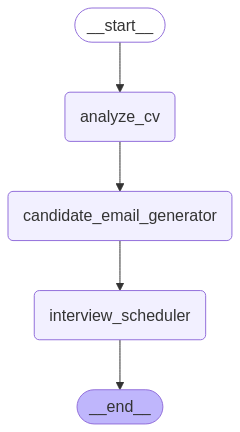

In [122]:
workflow = StateGraph(RecruitamentState)
workflow.add_node("analyze_cv",analyze_cv)
workflow.add_node("candidate_email_generator",candidate_email_generator)
workflow.add_node("interview_scheduler", interview_scheduler)
workflow.set_entry_point("analyze_cv")
workflow.add_edge("analyze_cv", "candidate_email_generator")
workflow.add_edge("candidate_email_generator", "interview_scheduler")
workflow.add_edge("interview_scheduler", END)
# return workflow.compile()
    # return workflow.compile(checkpointer=self.checkpointer)
graph = workflow.compile()
graph